# Milestone 3: EDA, Planning, and Setting Goals

[Due 4/18: Instructions](https://edstem.org/us/courses/74185/lessons/130679/slides/736236)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import utils.preprocessing as pp
import utils.visualization as viz


## Data Description


Instructions: Provide any missing information from Milestone 2 based on the feedback you received from your grader. 

In [2]:
satCat_current = pd.DataFrame(pp.loadUnprocessedSatCat_current("../data/satcat.zip")).set_index("NORAD_CAT_ID")
satCat_decayed = pd.DataFrame(pp.loadUnprocessedSatCat_decayed("../data/satcat.zip")).set_index("NORAD_CAT_ID")
snapshot_states = pp.loadSeveralYearsOfUnprocessedStates(["../data/snapshots_2023.zip","../data/snapshots_2024_p1.zip","../data/snapshots_2024_p2.zip","../data/snapshots_2025.zip"])
aggregatedData, uncataloged_states, nDuplicatesFound = pp.deduplicateAndMergeDataSources(snapshot_states, satCat_current, satCat_decayed)

df = pd.DataFrame(aggregatedData)
df.shape

(1034009, 20)

In [9]:
# remove unknown
df = df[df['TYPE'] != 'UNKNOWN']
df.shape

(1011052, 20)

## Summary of the Data


Instructions

Provide the shape of the data, data types, and descriptive statistics such as mean, max, and dtypes. Additionally, provide a summary of the features of the data, including histograms, correlation plots, and clustering plots as appropriate. 

<table>
    <tr>
        <th>Include in Model</th> <th>Feature</th> <th>Data Type</th> <th>Units</th><th>Description</th>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NAME</td> <td>String</td> <td>-</td> <td>name of satellite</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NUMBER</td> <td>String</td> <td>-</td> <td>NORAD assigned RSO number</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes (Response)</td> <td>TYPE</td> <td>String/Enum</td> <td>-</td> <td>type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>RCS</td> <td>String/Enum</td> <td>-</td> <td>encoding of object size</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>IS_CURRENT</td> <td>Boolean</td> <td>-</td> <td>whether or not the object has decayed since we started collecting catalog data</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>REGIME</td> <td>String/Enum</td> <td>-</td> <td>orbital regime of data</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>EPOCH</td> <td>Float</td> <td>Year/Day of Year/Fraction</td> <td>validity time for state</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>INCL</td> <td>Float</td> <td>Degree</td> <td>orbit inclination</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>where the orbital object rises relative to longitude</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ECC</td> <td>Float </td> <td>[0,1]</td> <td>measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>MEAN_ANOM</td> <td>Float</td> <td>Degree</td> <td>where the object is at epoch in orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>revolutions per day given orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>furthest orbit gets from earth</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>closest orbit gest from earth</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day2</td> <td>ballistic coefficient measure</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>COUNTRY</td> <td>String</td> <td>-</td> <td>Country code pulled from Satellite Catalog</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE1</td> <td>String</td> <td>-</td> <td>first line of TLE</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE2</td> <td>String</td> <td>-</td> <td>second line of TLE</td>
    </tr>
</table>


In [4]:
df.head(2)

,NUMBER,NAME,TYPE,RCS,IS_CURRENT,REGIME,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,COUNTRY,LINE1,LINE2
0,11,VANGUARD 2,PAYLOAD,MEDIUM,1,LEO,23227.529469,32.8786,39.4077,0.146176,291.2012,53.8788,11.872714,8116.494528,2924.83529,551.953765,0.000004,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,12,VANGUARD R/B,ROCKET BODY,MEDIUM,1,LEO,23227.463430,32.8971,270.9551,0.165991,26.7664,340.9673,11.457434,8311.452812,3312.97502,553.730604,0.000006,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


In [10]:
df.describe()

,IS_CURRENT,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER
count,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06
mean,9.295101e-01,2.394033e+04,6.769199e+01,1.791879e+02,4.443714e-02,1.679667e+02,1.918668e+02,1.255885e+01,1.085167e+04,5.408207e+03,3.538930e+03,9.569788e-05
std,2.559710e-01,6.208343e+02,2.908439e+01,1.064258e+02,1.483912e-01,9.912299e+01,1.026505e+02,4.473118e+00,9.947967e+03,1.190155e+04,9.231346e+03,2.851011e-03
min,0.000000e+00,2.307400e+04,3.000000e-04,2.000000e-04,1.000000e-06,1.800000e-03,1.000000e-04,3.183586e-02,6.486968e+03,1.225964e+02,7.893477e+01,-5.779533e-02
25%,1.000000e+00,2.327437e+04,5.305310e+01,8.530457e+01,1.819000e-04,8.704080e+01,9.466045e+01,1.313470e+01,6.925375e+03,5.484600e+02,5.391871e+02,4.300000e-07
50%,1.000000e+00,2.409250e+04,7.145945e+01,1.761789e+02,1.527800e-03,1.480048e+02,2.139979e+02,1.433189e+01,7.159229e+03,8.266858e+02,6.785810e+02,1.052000e-05
75%,1.000000e+00,2.427532e+04,9.759410e+01,2.738752e+02,8.646425e-03,2.630657e+02,2.744034e+02,1.506391e+01,7.587902e+03,1.336963e+03,9.559758e+02,6.325000e-05
max,1.000000e+00,2.507500e+04,1.527004e+02,3.600000e+02,9.650900e-01,3.599992e+02,3.600000e+02,1.661652e+01,4.205240e+05,5.395501e+05,2.887417e+05,1.000000e+00


In [ ]:
# TODO histogram of numerical features per instructions

In [4]:
response = 'TYPE'
X_exclude = ['NUMBER', 'NAME','RCS', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2']
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_ANOM', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER']

In [41]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df[X_numerical]), columns=X_numerical)
df_scaled.reset_index(drop=True, inplace=True)
df_response = df[[response]]
df_response.reset_index(drop=True, inplace=True)
df_exc = df[X_exclude]
df_exc.reset_index(drop=True, inplace=True)
df_scaled = pd.concat([df_response, df_scaled, df_exc], axis=1)
df_scaled.head(2)

,TYPE,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,NUMBER,NAME,RCS,IS_CURRENT,REGIME,EPOCH,COUNTRY,LINE1,LINE2
0,PAYLOAD,-1.196979,-1.313405,0.685616,1.243249,-1.344251,-0.153392,-0.274948,-0.208660,-0.323569,-0.032034,11,VANGUARD 2,MEDIUM,1,LEO,23227.529469,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,ROCKET BODY,-1.196343,0.862265,0.819142,-1.424497,1.452507,-0.246231,-0.255350,-0.176047,-0.323377,-0.031479,12,VANGUARD R/B,MEDIUM,1,LEO,23227.463430,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


## Data Analysis 

Instructions

- Identify patterns, trends, and outliers in the data. Additionally, explore the relationships between variables and identify any potential confounding variables that may impact the analysis.

- Meaningful Insights: Based on your analysis of the data, provide meaningful insights. Meaningful insights are those that connect back to your problem and are relevant to your specific context. Any insights should be well-supported by the data, provide actionable recommendations, and have a brief justification for why or how it’s important to the project. 

- Clean and Labeled Visualizations: Visualizations are important components of EDA and should be clean, labeled, and well-presented. You need to ensure that your visualizations are easy to understand and can be included in their final presentation slides or report. Anyone that reads your EDA should be able to understand what is depicted in the plots just by looking at them. Viz's that are not labeled correct will result in a loss of pts. 

### Correlation between Elements

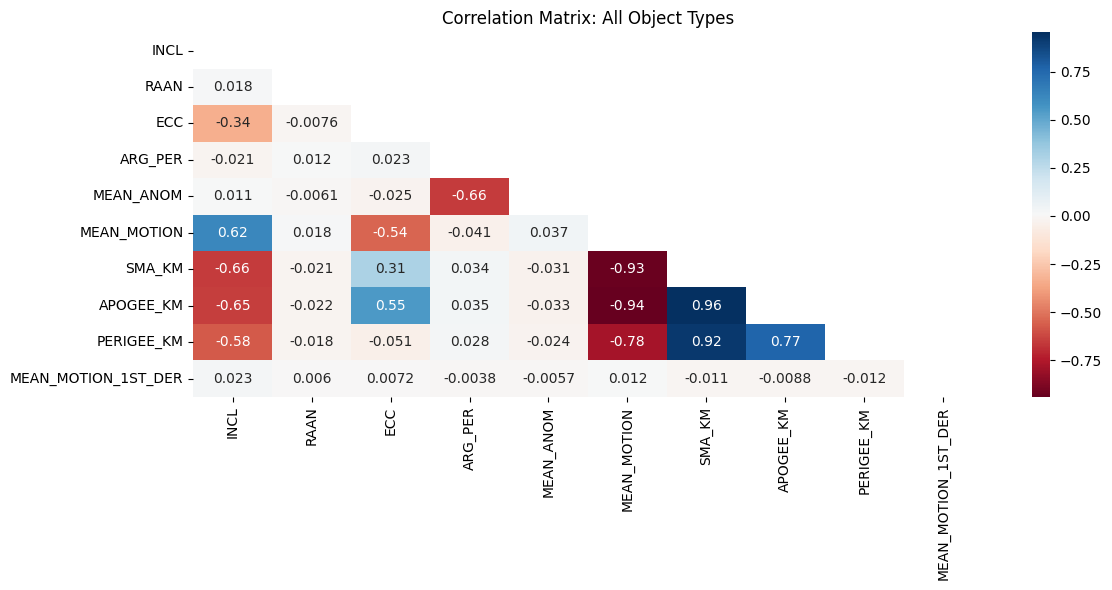

In [20]:
df_to_use = df_scaled

plt.figure(figsize=(12, 6))
corr = df_to_use[X_numerical].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap='RdBu', annot=True)
plt.title('Correlation Matrix: All Object Types')
plt.tight_layout()
plt.show()

##### Patterns Discovered in Correlation Matrix

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>


<table>
    <tbody>
        <tr>
            <th>Values</th>
            <th>Correlation</th>
            <th>Pattern</th>
            <th>Explanation</th>
        </tr>
        <tr>
            <th>Eccentricity vs. Inclination</th>
            <td>Slight Negative</td>
            <td>A</td>
            <td>Eccentricity describes the shape of an orbit: small values indicate a more circular orbit, while large values indicate a more elliptical one. A negative correlation suggests that orbits with higher inclination tend to be more circular in shape (lower eccentricity), while orbits with lower inclinations tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Inclination</th>
            <td>Positive</td>
            <td>B</td>
            <td>Mean motion refers to the number of times an object completes a rotation per day. Larger values indicate lower Earth orbits (which have more rotations per day). A positive correlation with inclination suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Semi-major Axis vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>The semi-major axis represents the longest semi-diameter of an orbit. Smaller values correspond to orbits closer to Earth. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Apogee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Apogee refers to the furthest point an object reaches from Earth in its orbit. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Perigee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Perigee is the closest point an object reaches to Earth in its orbit. A negative correlation with inclination again suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Eccentricity</th>
            <td>Negative</td>
            <td>C</td>
            <td>A negative correlation with mean motion indicates that more circular orbits (i.e., orbits with eccentricity closer to zero) will have a higher mean motion, meaning they will be closer to Earth.</td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Eccentricity</th>
            <td>Slight Positive</td>
            <td>C</td>
            <td>A positive correlation suggests higher Earth orbits tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Apogee vs. Eccentricity</th>
            <td>Positive</td>
            <td>C</td>
            <td>Orbits with higher apogees (furthest distance orbit goes from Earth) tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Mean Anomaly vs. Argument of Perigee</th>
            <td>Negative</td>
            <td>Likely Meaningless</td>
            <td>Mean anomaly is an angle that describes how much an orbit has been completed at a given time. Because of its connection to the epoch, we may want to drop it from our model. The argument of Perigee describes the orientation of the orbit in space. Mean anomaly is measured relative to the argument of perigee. Because mean anomaly is relative to when the orbit was epoched, we don't think that this correlation is meaningful. </td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large semi-major axis means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large apogee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Mean Motion</th>
            <td>Strong Negative</td>
            <td>Trivial</td>
            <td>Large perigee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Apogee is a subsection of the semi-major axis, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Apogee</th>
            <td>Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
    </tbody>
</table>


##### Conclusions

1. Apogee, perigee, and semi-major axis encode simlilar/overlapping concepts. Some combination of these features might need to be dropped.

2. Mean anomaly is relative to epoch time and doesn't describe an orbit's shape. We should consider dropping this feature in our model.

### Principal Component Analysis (PCA)

In [58]:
def pca_plot(pca_result, labels, label_info):

    type_labels, type_categories = pd.factorize(labels)
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=type_labels, cmap='tab10', alpha=0.7, edgecolors='none')
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title("PC 1&2 Highlighted by "+label_info)
    plt.grid(True)
    legend_labels = {i: type_categories[i] for i in range(len(type_categories))}
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10) 
           for i in legend_labels]
    plt.legend(handles, legend_labels.values(), title=label_info)
    plt.show()


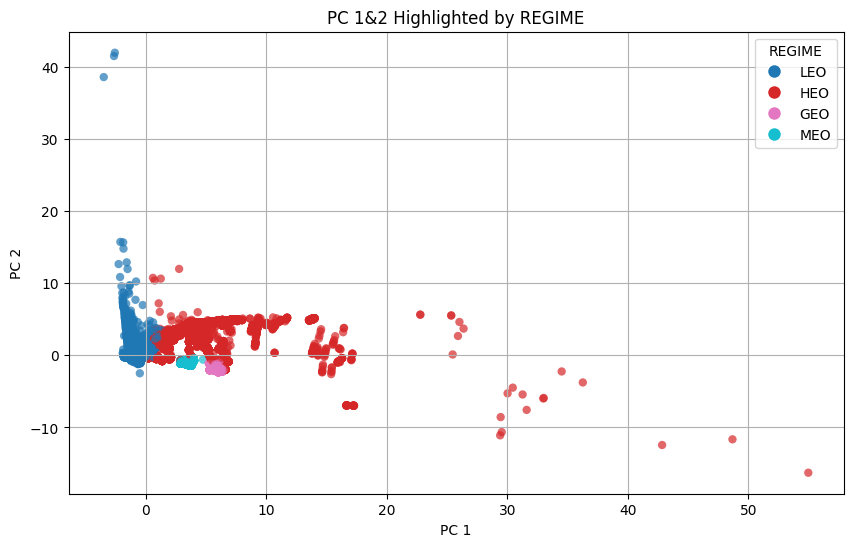

In [72]:
#df_scaled_rcs_dummies = pd.get_dummies(df_scaled, columns=['RCS'])
df_scaled_rcs_dummies = df_scaled
df_scaled_rcs_dummies = df_scaled_rcs_dummies.drop(columns=['TYPE','NUMBER', 'NAME', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2', 'MEAN_ANOM', 'RCS'])


pca = PCA(n_components=len(df_scaled_rcs_dummies.columns))  
pca_result = pca.fit_transform(df_scaled_rcs_dummies)

pca_plot(pca_result, df_scaled["REGIME"], "REGIME")



## Summary of findings


Instructions: Summarize your findings in a clear and concise manner. This can be achieved through the use of visualizations and captions that highlight the most important insights gained through the analysis.

## (Revised) Project Question


Instructions: Based on the insights gained through EDA, you should develop a clear project/research question that will guide your analysis. This question should be well-defined, specific to the problem at hand, and an improvement from the initial project proposal.